In [20]:
# Importing tests -> Succesful on 15/02/2026

import time
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from typing import Dict
import matplotlib.pyplot as plt



In [21]:
import tensorflow_recommenders as tfrs

## Helpers

Functions used along the notebook too complex or used repeatedly to be included as inline cells

In [22]:
def calculate_pseudo_rating(sales_df, half_life_days=720, reference_date=None):
    """
    Transforms raw transactional sales data into a continuous affinity score 
    using logarithmic scaling and exponential time decay.
    """
    # 1. Create a working copy to avoid SettingWithCopy warnings
    df = sales_df.copy()
    
    # 2. Ensure correct data types
    df['day'] = pd.to_datetime(df['day'])
    df['units'] = pd.to_numeric(df['units'], errors='coerce').fillna(0)
    
    # 3. Establish the "Present Day" to calculate Delta T
    if reference_date is None:
        reference_date = df['day'].max()
    else:
        reference_date = pd.to_datetime(reference_date)
        
    # 4. Calculate Days Ago (Delta t)
    df['days_ago'] = (reference_date - df['day']).dt.days
    # Prevent negative days if a future reference_date is accidentally passed
    df['days_ago'] = df['days_ago'].clip(lower=0) 
    
    # 5. Calculate Lambda based on the half-life
    decay_lambda = np.log(2) / half_life_days
    
    # 6. Apply the formula: ln(1 + Units) * e^(-lambda * days_ago)
    df['log_units'] = np.log1p(df['units'])
    df['decay_weight'] = np.exp(-decay_lambda * df['days_ago'])
    df['transaction_affinity'] = df['log_units'] * df['decay_weight']
    
    # 7. Aggregate up to the User-Item level
    # If a client bought the same product 5 times, we sum their decayed affinities
    return df

In [23]:
def create_train_test_tf_datasets(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    predicting_column: str,
    identifiers: list[str],
):
    """
    Creates TensorFlow datasets from pandas DataFrames for TFRS ranking.

    Args:
        train_df: The training DataFrame.
        test_df: The testing DataFrame.
        predicting_column: String name of the target/label column.
        identifiers: List of string names for the ID columns.

    Returns:
        train_ds, test_ds: tf.data.Dataset objects.
    """

    # Construct the dictionary for Training
    train_dict = {col: train_df[col].values.astype(str) for col in identifiers}
    train_dict[predicting_column] = train_df[predicting_column].values.astype(float)

    # Construct the dictionary for Testing
    test_dict = {col: test_df[col].values.astype(str) for col in identifiers}
    test_dict[predicting_column] = test_df[predicting_column].values.astype(float)

    # Convert dictionaries to slices
    train_ds = tf.data.Dataset.from_tensor_slices(train_dict)
    test_ds = tf.data.Dataset.from_tensor_slices(test_dict)

    return train_ds, test_ds


In [24]:
def visualize_training(history, metric, loss, save=False):
    """
    Visualizes the training process for a given Loss and Metric.
    
    Args:
        history (dict or History): The training history object or dictionary produced after .fit() call
        metric (str): Key for the metric (e.g., 'root_mean_squared_error').
        loss (str): Key for the loss (e.g., 'loss').
    """
    # 1. Extract the dictionary if passed the History object directly
    h_dict = history.history if hasattr(history, 'history') else history
    
    # Check if keys exist to avoid errors
    if loss not in h_dict or metric not in h_dict:
        raise ValueError(f"Keys '{loss}' or '{metric}' not found in history.")

    x_values = range(1, len(h_dict[loss]) + 1)
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # 2. Setup the Loss Axis (Left)
    color_loss = '#5BCEFA' # Light Blue
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss', color=color_loss, fontsize=12)
    line1 = ax1.plot(x_values, h_dict[loss], color=color_loss, label='Train Loss', lw=2.5)
    ax1.tick_params(axis='y', labelcolor=color_loss)
    ax1.grid(True, alpha=0.3)

    # 3. Create the Metric Axis (Right)
    ax2 = ax1.twinx() 
    color_metric = '#F5A9B8' # Light Pink
    
    # Cleanup label for display
    display_metric = metric.replace("_", " ").capitalize()
    ax2.set_ylabel(f'Metric: {display_metric}', color=color_metric, fontsize=12)
    line2 = ax2.plot(x_values, h_dict[metric], color=color_metric, label=display_metric, lw=2.5)
    ax2.tick_params(axis='y', labelcolor=color_metric)

    # 4. Merging legends into one box
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right', frameon=True)

    plt.title('Loss and Metric Temporal Evolution', fontsize=14)
    fig.tight_layout()

    # 5. Save and Close
    if save:
        plt.savefig('training_evolution.png', dpi=300)
    else:
        plt.show() # Uncomment if running in a local GUI environment
    plt.close(fig)

In [25]:
def evaluate_test_vs_train(train_history :dict, eval_history:dict ,metric_key :str ,loss_key: str  = "loss"):
    train_metric = train_history.history[metric_key][-1] # Assuming last epoch as the best lol
    eval_metric = eval_history[metric_key]
    train_loss = train_history.history[loss_key][-1] # Assuming last epoch as the best lol
    eval_loss = eval_history[loss_key]

    metric_ratio = train_metric/eval_metric
    loss_ratio = train_loss/eval_loss

    print(f"{metric_key} ratio train vs test:   {metric_ratio}")
    print(f"{loss_key} ratio train vs test:   {loss_ratio}")

# Recommenders Introduction
Based on [Basic Ranking Models](https://www.tensorflow.org/recommenders/examples/basic_ranking)


Real-world recommender systems are often composed of two stages:

- The retrieval stage is responsible for selecting an initial big set of candidates from all possible candidates. The main objective of this model is to efficiently weed out all candidates that the user/customer is not interested in. Because the retrieval model may be dealing with millions of candidates, it has to be computationally efficient. 
- The ranking stage takes the outputs of the retrieval model and fine-tunes them to select the best possible handful of recommendations based on a numeric valuation that the user/client to the product. This numeric value can be a explicit such a rating or implicit 


This notebook focuses on developing a model able to rank products based on a numerical variable that represents how much a customer "likes" a product, i.e the ranking stage



# Modelling and implicit Rating
The data used for this demonstrations comes [from this dataset](https://github.com/dluckyaction/datasets/blob/main/sales/README.md): *Sales data from beverage products on B2B setting*. 

## Explicit vs Implicit rating

Contrary to the example provided by tensorflow, sales data lack of a explicit valuation of the product by the customer. In order to create a ranking we work with a pseudo-rating approaches laid out in the following sections.

### Pseudo-Rating: 

It consists on engineering a continuous target variable $y_{u,i}$ (affinity of user $u$ to item $i$) based on their purchase history, and train the model using Mean Squared Error (MSE) just like the TensorFlow example. The following pseudo-rating definition is to be used:

$$y_{u,i} = \ln({\text{units}_{u,i}+1}) \times e^{-\lambda \cdot \Delta t}$$

where: 
- $\text{units}$ represent the units sold of a product to a customer $\text{i}$ 
- $\Delta t$ represents the time since the purchase.

Diving into each of the terms:

- $\ln{(1+units)}$ represents how relevant a purchase is. It is used cause, raw units are usually heavily skewed (e.g., buying 100 cheap screws vs. 1 expensive drill). logarithmic transformation dampens the effect.
- $e^{-\lambda \cdot \Delta t}$ represents the time-decaying effect: A purchase 100 days ago is less relevant than a purchase 5 days ago.
    - $\lambda$ is the decay constant, derived from the half-life ($t_{1/2}$) of a purchase's relevance: $\lambda = \frac{\ln(2)}{t_{1/2}}$. For example, if we choose a half-life of 180 days, a purchase's contribution to the affinity score is reduced by half after 6 months.
####  About the cumulative behaviour of $y_{u,i}$

For clients who purchase the same product multiple times, the final pseudo-rating will be considered the sum of these individual decayed pseudo-ratings, capturing the total "strength" of the relationship between the client and the product. This is a significant assumption that merits its own study. Specifically, some limitations can be:
 - Additivity: this heuristic assumes that three small purchases are equivalent to one large purchase of the same total volume (information loss)
 - Lack of Rejection Signal: This heuristic does not account for "negative" experiences (e.g., a customer buys a product once, finds it unprofitable or of low quality, and intentionally avoids it in the future). In such cases, the model would still see a "positive" signal where there is actually a "rejection."

However, for the scope of this notebook, we will assume $y_{u,i}$ is cumulative over purchases to provide a baseline for the Ranking Model's behavior.

# Methods

Two models are tried in this notebook. Both of them take as inputs  `product_code` and `client_code` as simple labels and try to calculate a sum of  pseudo-ratings per customer and client as defined above. The first of them tries to calculate it "raw" (without scaling) and will be referred as `model`.  The second one normalizes this variable in an effort to get better predictions and is called `normalized_model`. The loss used is Mean Squared Error and the metric its squared root (RMSE).

Data is split in a 80/20 temporal manner: we train with information from transactions ranging 80% of the time length of the sales set (`sales_df`)


# Conclusions

Results are unsuccesful. Both of the models perform horribly and seem to just try to overfit without even being able to do it. The RMSEs are too big (see results) and the ratio of RMSE in train set doubles (DOUBLES!!!) the one in test set. There are a couple of reasons to explain this bad results.


0. It is important to view not as a flaw in the Two-Tower logic, but as a mismatch between the data's nature and the model's configuration.

1. Temporal Blindness in Label Encoding : The pseudo-rating is designed to represent "affinity," but it compressed time into a single static number. By summing up historical transactions with a decay factor, we created a "Snapshot". The model learned who liked what on average, but it had no way of knowing when the next purchase or the past ones. 

2. High Variance and Scale Explosions: We initially ignored target normalization, which is catastrophic for Mean Squared Error (MSE). Pseudo-ratings were "unbounded". A heavy-duty wholesaler might have an affinity score of 150.0, while a small bar has 0.5. During training, the 150.0 value creates a massive "gradient shock." The model spends all its energy trying to reduce the error for that one giant client, effectively "forgetting" or ignoring the patterns of the other 229 smaller clients.

3. Not enough data: 22K transactions is not enough  to generalize patterns, added to the fact of the temporal blindness it leads to the model being failing (noisy) lookup table not able to find the differences between (product A, client B) and (product A, client C)


Next steps: Include time by using [Sequential Models](https://www.tensorflow.org/recommenders/examples/sequential_retrieval) or [featurization](https://www.tensorflow.org/recommenders/examples/featurization)


# Developement

## Data Preparation ETL


### Extractions

In [26]:
file_paths ={"clients":"https://raw.githubusercontent.com/dluckyaction/datasets/refs/heads/main/sales/clients.csv",
             "products":"https://raw.githubusercontent.com/dluckyaction/datasets/refs/heads/main/sales/products.csv",
             "sales":"https://raw.githubusercontent.com/dluckyaction/datasets/refs/heads/main/sales/sales.csv" } 

In [27]:
REFERENCE_DATE = "2025-12-17" # See why here: https://github.com/dluckyaction/datasets/blob/main/sales/README.md#sales-data
PRODUCT_HALF_LIFE_RELEVANCE = 90 # days at which the importance of a purchase halves

In [28]:
products_df = pd.read_csv(file_paths.get("products"))
sales_df = pd.read_csv(file_paths.get("sales"))

In [29]:
sales_df["day"]=pd.to_datetime(sales_df["day"])

### Calculate Pseudo-Rating

In [30]:
sales_df = sales_df.pipe(calculate_pseudo_rating,half_life_days=PRODUCT_HALF_LIFE_RELEVANCE, reference_date=REFERENCE_DATE)

### Transformation

In [31]:
# Converting purchase date into dates to be able to split train/test



#### Train test dataframes


In order to follow the "Basic" nature of this notebook, we are only using as inputs `product_code` and `client_code` as inputs. As the pseudorating metric we have build has a temporal dependency, **aggregation over `product_code` and `client_code`** is performed by summing app all pseudo-ratings. This is a bold choice that is should not be used in production models (production settings are always are time dependent) where this temporal dependencies must be included as part of the inputs. Following notebooks in this series will be discussing and approaching this issue further. 

In [32]:
# Cutoff date chosen to train set represent 80% of the dates of sales
cutoff_date = sales_df["day"].min()+(sales_df['day'].max() - sales_df['day'].min())*0.8
train_df = sales_df[sales_df["day"]<=cutoff_date].drop(columns=["day","units"]).groupby(["client_code","product_code"]).aggregate({"transaction_affinity":"sum"}).reset_index()
test_df = sales_df[sales_df["day"]>cutoff_date].drop(columns=["day","units"]).groupby(["client_code","product_code"]).aggregate({"transaction_affinity":"sum"}).reset_index()

##### Visualizing Pseudo Rating  (transaction affinity)

array([[<Axes: title={'center': 'transaction_affinity'}>]], dtype=object)

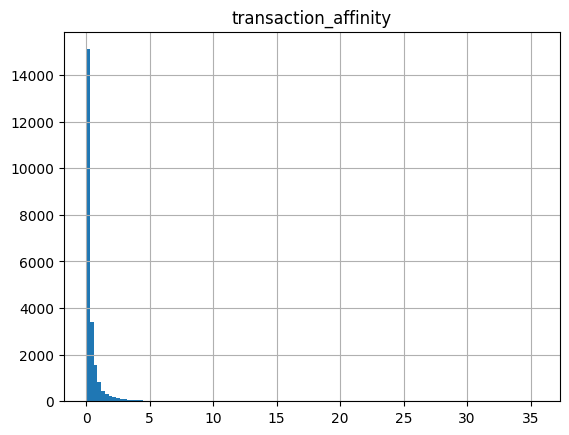

In [33]:
train_df.hist("transaction_affinity", bins=120)

In [34]:
train_df.transaction_affinity.describe()

count    22775.000000
mean         0.466162
std          1.227976
min          0.006125
25%          0.064420
50%          0.164830
75%          0.438626
max         35.509482
Name: transaction_affinity, dtype: float64

##### Visualizing Normalized Pseudo Rating  (transaction affinity)

In [35]:
normalized_affinity=(train_df.transaction_affinity-train_df.transaction_affinity.mean())/train_df.transaction_affinity.std()


<Axes: >

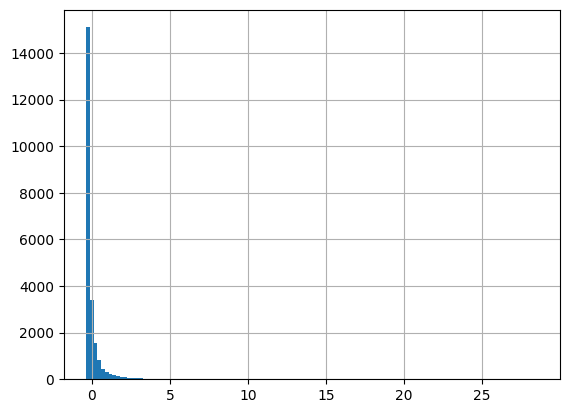

In [ ]:
normalized_affinity.hist(bins=120)
# It already heavily skewed following a power law. We'll get most likely rubishh  out of it.

In [37]:
normalized_affinity.describe()

count    2.277500e+04
mean     3.868597e-17
std      1.000000e+00
min     -3.746303e-01
25%     -3.271583e-01
50%     -2.453898e-01
75%     -2.242435e-02
max      2.853746e+01
Name: transaction_affinity, dtype: float64

#### Unique Clients/Products

Extraction of unique clients and products to define Product and Client models (towers)

In [38]:
unique_clients=sales_df.client_code.unique().to_numpy()
unique_products=sales_df.product_code.unique().to_numpy()

### Start up Tensorflow data structures

In order to correctly init the models, metrics and tasks on tensorflow, the dataframe and numpy arrays must be transformed into tensors. Here we build a function to do that in different cases:

In [39]:
# 1. Convert NumPy array to a TF Dataset (a stream of strings)
unique_product_tf_dataset = tf.data.Dataset.from_tensor_slices(unique_products)


##  Models

Building two Ranking models. For this scenario we only use the identification of customers and products.

## Parameters
*models parameters*

In [40]:
# Models parameters
EMBEDDING_DIMENSION = 6 # Size of the vectorial 
                         #representation of clients and products ids
EPOCHS = 20 # Number of epochs
LEARNING_RATE=0.01
HIDDEN_LAYERS_SIZES=[16,2]
# Data parameters
## Batch sizes
### train/test batches
TRAIN_BATCH_SIZE = 64
TEST_BATCH_SIZE = 8

# TODO Add layers parametrization


### Query/Clients and Candidate/Products models

### Ranking Model

Using 3 and a half submodels:

1) Client lookup layer to embedd clients
2) Customer lookup layer to embedd  products
3) Normalization layer to normalize pseudo-rating
4) Raing layer to predict pseudo-rating

In [41]:
class RankingModel(tf.keras.Model):

    def __init__(
        self,
        hidden_layer_sizes: list = [256, 64], # Parametrizing layers (like I was a god lol!)
        activation_hidden_layers: list[str, None] = ["relu", "relu"],
        normalize_target : bool = False
    ):
        super().__init__()

        # Compute embeddings for clients.
        # (see retrieval model notebook for more details https://github.com/dluckyaction/recommenders-tensorflow/blob/main/BasicTwoTowerModels.ipynb)
        self.clients_embeddings = tf.keras.Sequential(
            [
                tf.keras.layers.StringLookup(
                    vocabulary=unique_clients, mask_token=None
                ),
                # We add an additional embedding to account for unknown tokens.
                tf.keras.layers.Embedding(len(unique_clients) + 1, EMBEDDING_DIMENSION),
            ],
            name="clients_model",
        )

        # Compute embeddings for products.
        self.product_embeddings = tf.keras.Sequential(
            [
                tf.keras.layers.StringLookup(
                    vocabulary=unique_products, mask_token=None
                ),
                # We add an additional embedding to account for unknown tokens.
                tf.keras.layers.Embedding(
                    len(unique_products) + 1, EMBEDDING_DIMENSION
                ),
            ],
            name="products_model",
        )

        # Compute predictions.
        self.dense_layer_sizes = hidden_layer_sizes + [1]
        self.dense_layer_activations = activation_hidden_layers + [None]
        self.ratings = tf.keras.Sequential(
            [
                tf.keras.layers.Dense(size, activation=activ)
                for size, activ in zip(
                    self.dense_layer_sizes, self.dense_layer_activations
                )
            ]
        )
        
        # Create optional layer for normalization

        self.normalize_target=normalize_target
        if self.normalize_target:
            self.rating_normalization = tf.keras.layers.Normalization(axis=None)
            
    def call(self, inputs):
        """
        Model Call : calculate a rating based on inputs (client_id+client_product)
        """

        client, product = inputs

        client_embedding = self.clients_embeddings(client)
        product_embedding = self.product_embeddings(product)

        return self.ratings(tf.concat([client_embedding, product_embedding], axis=1))

### Loss and Metric

For simplicity we use built-in Tensorflow recommenders (TFRS) [Ranking Task](https://www.tensorflow.org/recommenders/api_docs/python/tfrs/tasks/Ranking). It wraps up two necessary processes:
- Computing the loss of our choice.
- Metric calculation -> Calculates a metric of our choice for further evaluation

In [42]:
task = tfrs.tasks.Ranking(
  loss = tf.keras.losses.MeanSquaredError(),
  metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

## Full Basic Ranking Model

To see the classes logic follow first TF tutorial on basic rtanking [here](https://www.tensorflow.org/recommenders/examples/sequential_retrieval)

In [43]:
class BasicRankingModel(tfrs.models.Model):

  def __init__(self,predict_field_name :str = "transaction_affinity",**kwargs):
    super().__init__()
    self.ranking_model: tf.keras.Model = RankingModel(**kwargs)
    self.task: tf.keras.layers.Layer = tfrs.tasks.Ranking(
      loss = tf.keras.losses.MeanSquaredError(),
      metrics=[tf.keras.metrics.RootMeanSquaredError()]

    )
    self.predict_field_name = predict_field_name

  def call(self, features: Dict[str, tf.Tensor]) -> tf.Tensor:
    return self.ranking_model(
        (features["client_code"], features["product_code"]))
  
  def compute_loss(self, features: Dict[str, tf.Tensor], training=False) -> tf.Tensor:
    labels = features.pop(self.predict_field_name)

    # Normalize
    if self.ranking_model.normalize_target:
      labels = self.ranking_model.rating_normalization(labels)

    rating_predictions = self(features)

    # The task computes the loss and the metrics.
    return self.task(labels=labels, predictions=rating_predictions)
  
  # Method added to calculate 
  def prepare_normalization(self, dataset):
        """
        Public method to calibrate the model if normalization is enabled.
        """
        if self.ranking_model.normalize_target:
            print("Calibrating target normalization")
            # Extract only the target field for adaptation
            target_data = dataset.map(lambda x: x[self.predict_field_name])
            self.ranking_model.rating_normalization.adapt(target_data)
        else:
            print("Normalization disabled. Skipping calibration.")

### Train

As we use different techniques to estimate a implicit rating, this section is split into different susbsections for those different approaches. As it was done in the previous notebook,due to the temporal nature of sales data,  `sales_df` is separated into train and test based on a cutoff date that split the number of days into 80/20 sets.-

In [44]:
# Cutoff date chosen to train set represent 80% of the dates of sales
cutoff_date = sales_df["day"].min()+(sales_df['day'].max() - sales_df['day'].min())*0.8

#### Pseudo Rating (transaction affinity)

In [45]:
train_pseudo_rating_df = (
    sales_df[sales_df["day"] <= cutoff_date]
    .drop(columns=["day", "units"])
    .groupby(["client_code", "product_code"])
    .aggregate({"transaction_affinity": "sum"})
    .reset_index()
)
test_pseudo_rating_df = (
    sales_df[sales_df["day"] > cutoff_date]
    .drop(columns=["day", "units"])
    .groupby(["client_code", "product_code"])
    .aggregate({"transaction_affinity": "sum"})
    .reset_index()
)


# Into tensors
train_pseudo_rating_tf_dataset, test_pseudo_rating_tf_dataset = (
    create_train_test_tf_datasets(
        train_pseudo_rating_df,
        test_pseudo_rating_df,
        predicting_column="transaction_affinity",
        identifiers=["product_code","client_code"]
    )
)

In [46]:
model = BasicRankingModel(predict_field_name="transaction_affinity",hidden_layer_sizes=HIDDEN_LAYERS_SIZES)
model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=LEARNING_RATE))

In [47]:
cached_train = train_pseudo_rating_tf_dataset.shuffle(len(train_df)).batch(TRAIN_BATCH_SIZE).cache()
cached_test = test_pseudo_rating_tf_dataset.batch(TEST_BATCH_SIZE).cache()  

In [48]:
# Saving results of fit (history) is useful to visualize training process
history = model.fit(cached_train, epochs=EPOCHS)

Epoch 1/20
356/356 [==============================] - 2s 2ms/step - root_mean_squared_error: 1.2512 - loss: 1.5635 - regularization_loss: 0.0000e+00 - total_loss: 1.5635
Epoch 2/20
356/356 [==============================] - 1s 2ms/step - root_mean_squared_error: 1.2251 - loss: 1.4992 - regularization_loss: 0.0000e+00 - total_loss: 1.4992
Epoch 3/20
356/356 [==============================] - 1s 2ms/step - root_mean_squared_error: 1.2175 - loss: 1.4805 - regularization_loss: 0.0000e+00 - total_loss: 1.4805
Epoch 4/20
356/356 [==============================] - 1s 3ms/step - root_mean_squared_error: 1.2022 - loss: 1.4435 - regularization_loss: 0.0000e+00 - total_loss: 1.4435
Epoch 5/20
356/356 [==============================] - 1s 3ms/step - root_mean_squared_error: 1.1804 - loss: 1.3914 - regularization_loss: 0.0000e+00 - total_loss: 1.3914
Epoch 6/20
356/356 [==============================] - 1s 2ms/step - root_mean_squared_error: 1.1540 - loss: 1.3299 - regularization_loss: 0.0000e+00 -

##### Visualize Train

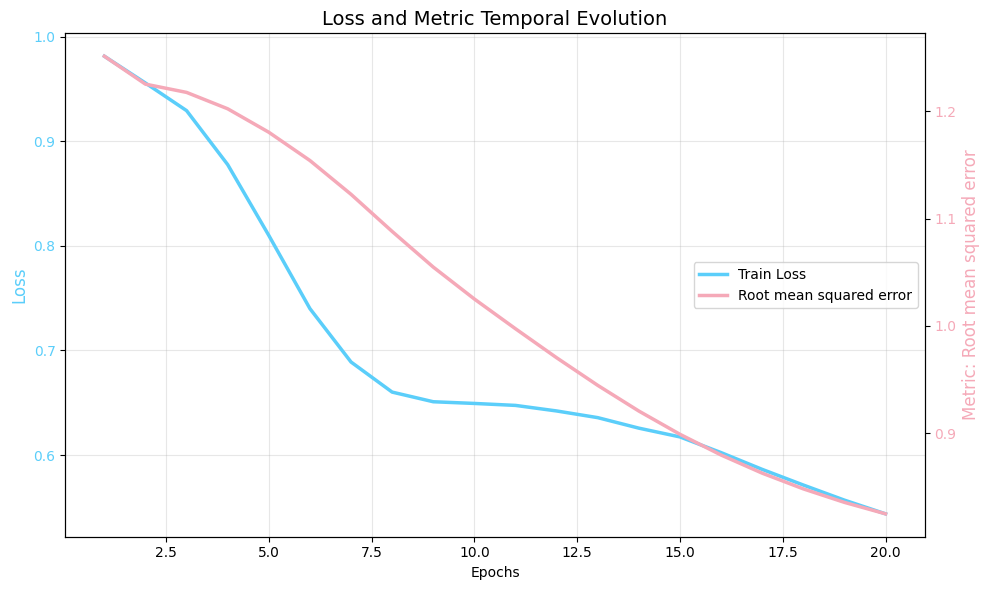

In [49]:
metric_key = "root_mean_squared_error"
loss_key = "loss"
visualize_training(history,metric_key,loss_key)

#### Normalized Pseudo Rating 

TODO: Say here why we add normalization Layer
TODO: Implement call with normalization



In [50]:
model_normalized = BasicRankingModel(normalize_target=True)
model_normalized.prepare_normalization(train_pseudo_rating_tf_dataset) # Added a method to prepare data
model_normalized.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=LEARNING_RATE))


Calibrating target normalization


In [51]:
cached_train = train_pseudo_rating_tf_dataset.shuffle(len(train_df)).batch(TRAIN_BATCH_SIZE).cache()
cached_test = test_pseudo_rating_tf_dataset.batch(TEST_BATCH_SIZE).cache()  

In [52]:
# Saving results of fit (history) is useful to visualize training process
history_normalized = model_normalized.fit(cached_train, epochs=EPOCHS)

Epoch 1/20


356/356 [==============================] - 1s 2ms/step - root_mean_squared_error: 0.9963 - loss: 0.9904 - regularization_loss: 0.0000e+00 - total_loss: 0.9904
Epoch 2/20
356/356 [==============================] - 1s 2ms/step - root_mean_squared_error: 0.9773 - loss: 0.9528 - regularization_loss: 0.0000e+00 - total_loss: 0.9528
Epoch 3/20
356/356 [==============================] - 1s 2ms/step - root_mean_squared_error: 0.9298 - loss: 0.8625 - regularization_loss: 0.0000e+00 - total_loss: 0.8625
Epoch 4/20
356/356 [==============================] - 1s 2ms/step - root_mean_squared_error: 0.8302 - loss: 0.6875 - regularization_loss: 0.0000e+00 - total_loss: 0.6875
Epoch 5/20
356/356 [==============================] - 1s 2ms/step - root_mean_squared_error: 0.7296 - loss: 0.5312 - regularization_loss: 0.0000e+00 - total_loss: 0.5312
Epoch 6/20
356/356 [==============================] - 1s 2ms/step - root_mean_squared_error: 0.6833 - loss: 0.4660 - regularization_loss: 0.0000e+00 - total_loss

##### Visualize Train



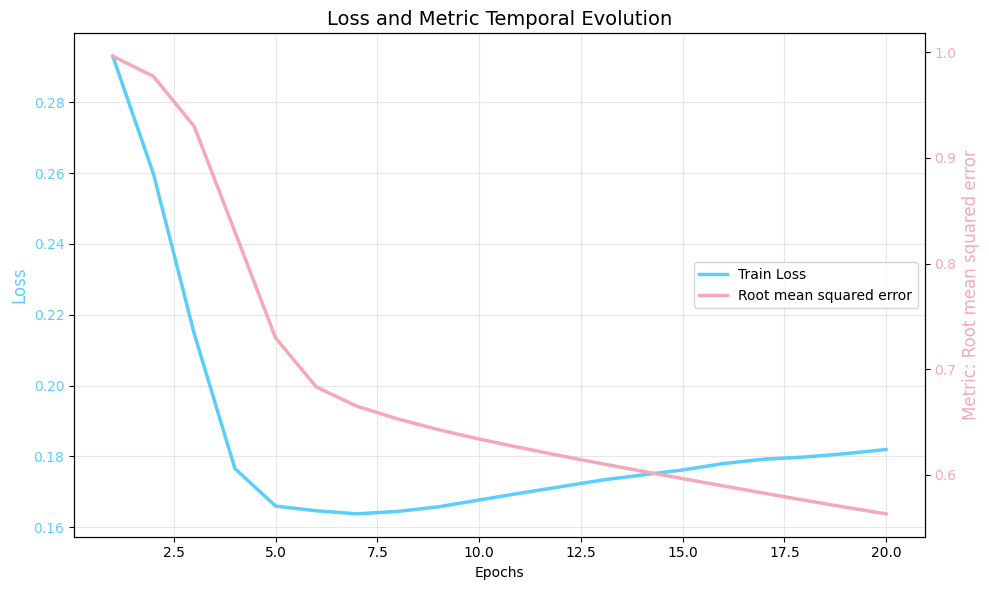

In [53]:
metric_key = "root_mean_squared_error"
loss_key = "total_loss"
visualize_training(history_normalized,metric_key,loss_key)

### Model Evaluation

Make predictions from test dataset

#### Pseudo Rating

In [54]:
evaluation = model.evaluate(cached_test, return_dict=True)

2018/2018 [==============================] - 3s 1ms/step - root_mean_squared_error: 1.5160 - loss: 2.3035 - regularization_loss: 0.0000e+00 - total_loss: 2.3035


#### Normalized Pseudo Rating

In [55]:
evaluation_normalized = model_normalized.evaluate(cached_test, return_dict=True)

2018/2018 [==============================] - 3s 1ms/step - root_mean_squared_error: 1.0482 - loss: 1.1004 - regularization_loss: 0.0000e+00 - total_loss: 1.1004


#### Comparing results

In [56]:
# This is a toy evaluation. For production grade models
# be professional and use optuna and mlflow (or equivalent tools) 
# to automate evaluation
compare_metric = 'root_mean_squared_error'
loss= 'loss'
histories= [(history,evaluation,"Ranking Model using Pseudo Rating"),(history_normalized,evaluation_normalized, "Normalized Ranking Model using Pseudo Rating")]
for train_history,eval_history,model_name in histories:
    print(f"Evaluation for {model_name} ")
    evaluate_test_vs_train(train_history , eval_history,compare_metric,loss_key=loss)
    print("\n")



Evaluation for Ranking Model using Pseudo Rating 
root_mean_squared_error ratio train vs test:   0.5442067186867978
loss ratio train vs test:   0.042255527701798766


Evaluation for Normalized Ranking Model using Pseudo Rating 
root_mean_squared_error ratio train vs test:   0.5373405670015218
loss ratio train vs test:   0.041236131561478886


